# XYZ Cab Company Investment Analysis

##  Problem Statement
XYZ, a private US firm, is evaluating investment opportunities in the US cab market. They’ve collected data from two cab companies and want to determine which company has a stronger growth trajectory, better customer base, and overall more potential for future returns.

##  Objective
The goal is to perform an in-depth analysis using:
- Exploratory Data Analysis (EDA)
- Hypothesis testing
- Merging & Feature Engineering
- Evaluation Metrics

A set of actionable insights and recommend which company is the better investment choice will be provided.


In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


##  Section 1: Data Intake Report

Four CSV files was provided:

1. `Cab_Data.csv` – Contains trip-level data from two cab companies.
2. `Customer_ID.csv` – Contains customer demographic information.
3. `Transaction_ID.csv` – Contains transaction-level and payment information.
4. `City.csv` – Contains population and cab user statistics per city.

The structure and size of each dataset is summarize below.


In [83]:
# Load datasets
cab_data = pd.read_csv("Cab_Data.csv")
city_data = pd.read_csv("City.csv")
customer_id = pd.read_csv("Customer_ID.csv")
transaction_id = pd.read_csv("Transaction_ID.csv")

# Summary function
def get_data_summary(df, file_name):
    return {
        "File Name": file_name,
        "Total Rows": df.shape[0],
        "Total Columns": df.shape[1],
        "Base Format": ".csv",
        "Size (MB)": round(df.memory_usage(deep=True).sum() / (1024**2), 2)
    }

# Collect summaries
summaries = [
    get_data_summary(cab_data, "Cab_Data.csv"),
    get_data_summary(city_data, "City.csv"),
    get_data_summary(customer_id, "Customer_ID.csv"),
    get_data_summary(transaction_id, "Transaction_ID.csv")
]

# Display as DataFrame
summary_df = pd.DataFrame(summaries)
summary_df


,File Name,Total Rows,Total Columns,Base Format,Size (MB)
0,Cab_Data.csv,359392,7,.csv,54.44
1,City.csv,20,3,.csv,0.00
2,Customer_ID.csv,49171,4,.csv,3.65
3,Transaction_ID.csv,440098,3,.csv,28.96


##  Section 2: Exploratory Data Analysis (EDA)

Each dataset will be exploreto:
- Inspect structure and data types
- Check for missing values and duplicates
- Detect potential outliers
- Understand how datasets relate to each other


In [84]:
# Overview of Cab_Data
print("Cab_Data:")
print(cab_data.info())
print("\nMissing Values:\n", cab_data.isnull().sum())
print("-" * 50)

# Overview of Customer_ID
print("Customer_ID:")
print(customer_id.info())
print("\nMissing Values:\n", customer_id.isnull().sum())
print("-" * 50)

# Overview of Transaction_ID
print("Transaction_ID:")
print(transaction_id.info())
print("\nMissing Values:\n", transaction_id.isnull().sum())
print("-" * 50)

# Overview of City
print("City:")
print(city_data.info())
print("\nMissing Values:\n", city_data.isnull().sum())
print("-" * 50)


Cab_Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359392 entries, 0 to 359391
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Transaction ID  359392 non-null  int64  
 1   Date of Travel  359392 non-null  int64  
 2   Company         359392 non-null  object 
 3   City            359392 non-null  object 
 4   KM Travelled    359392 non-null  float64
 5   Price Charged   359392 non-null  float64
 6   Cost of Trip    359392 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 19.2+ MB
None

Missing Values:
 Transaction ID    0
Date of Travel    0
Company           0
City              0
KM Travelled      0
Price Charged     0
Cost of Trip      0
dtype: int64
--------------------------------------------------
Customer_ID:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49171 entries, 0 to 49170
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  --

In [85]:
# Count duplicates
duplicates = {
    "Cab_Data": cab_data.duplicated().sum(),
    "Customer_ID": customer_id.duplicated().sum(),
    "Transaction_ID": transaction_id.duplicated().sum(),
    "City": city_data.duplicated().sum()
}

pd.DataFrame.from_dict(duplicates, orient="index", columns=["Duplicate Rows"])


,Duplicate Rows
Cab_Data,0
Customer_ID,0
Transaction_ID,0
City,0


In [86]:
# Check Numeric Distributions
# Basic statistical summaries
cab_data.describe()


,Transaction ID,Date of Travel,KM Travelled,Price Charged,Cost of Trip
count,3.593920e+05,359392.000000,359392.000000,359392.000000,359392.000000
mean,1.022076e+07,42964.067998,22.567254,423.443311,286.190113
std,1.268058e+05,307.467197,12.233526,274.378911,157.993661
min,1.000001e+07,42371.000000,1.900000,15.600000,19.000000
25%,1.011081e+07,42697.000000,12.000000,206.437500,151.200000
50%,1.022104e+07,42988.000000,22.440000,386.360000,282.480000
75%,1.033094e+07,43232.000000,32.960000,583.660000,413.683200
max,1.044011e+07,43465.000000,48.000000,2048.030000,691.200000


##  Section 3: Hypothesis Generation

Based on the problem context and cab industry trends, the following hypotheses are analyzed:

###  Hypotheses:

1. Company A has more customers than Company B across most cities.
2. Average revenue per ride is significantly higher for one company.
3. Customer demographics (age/income) are correlated with ride frequency.
4. here is seasonal variation in cab usage (e.g., summer and holidays).
5. Cab usage is proportional to city population and number of cab users.
6. Mode of payment affects average ride amount or frequency.
7. There is a positive relationship between number of customers and company margin.


##  Section 4: Data Preparation and Merging

The four data sources will be merge into one dataset by following these relationships:

- `Cab_Data.csv` to `Transaction_ID.csv` via `Transaction ID`
- `Transaction_ID.csv` to `Customer_ID.csv` via `Customer ID`
- `Cab_Data.csv` to `City.csv` via `City`

This merge dataset will be used for all analysis and visualization going forward.


In [87]:
# Step 1: Merge Cab Data with Transaction Data
cab_transaction = pd.merge(cab_data, transaction_id, how="left", on="Transaction ID")

# Step 2: Merge with Customer Data
cab_customer = pd.merge(cab_transaction, customer_id, how="left", on="Customer ID")

# Step 3: Merge with City Data
merge_data = pd.merge(cab_customer, city_data, how="left", on="City")

# Convert date to datetime
merge_data["Date of Travel"] = pd.to_datetime(merge_data["Date of Travel"])

# Preview master data
merge_data.head()


,Transaction ID,Date of Travel,Company,City,KM Travelled,Price Charged,Cost of Trip,Customer ID,Payment_Mode,Gender,Age,Income (USD/Month),Population,Users
0,10000011,1970-01-01 00:00:00.000042377,Pink Cab,ATLANTA GA,30.45,370.95,313.635,29290,Card,Male,28,10813,"814,885","24,701"
1,10000012,1970-01-01 00:00:00.000042375,Pink Cab,ATLANTA GA,28.62,358.52,334.854,27703,Card,Male,27,9237,"814,885","24,701"
2,10000013,1970-01-01 00:00:00.000042371,Pink Cab,ATLANTA GA,9.04,125.20,97.632,28712,Cash,Male,53,11242,"814,885","24,701"
3,10000014,1970-01-01 00:00:00.000042376,Pink Cab,ATLANTA GA,33.17,377.40,351.602,28020,Cash,Male,23,23327,"814,885","24,701"
4,10000015,1970-01-01 00:00:00.000042372,Pink Cab,ATLANTA GA,8.73,114.62,97.776,27182,Card,Male,33,8536,"814,885","24,701"


##  Section 5: Insights and Visualizations

Visualizations and grouped statistics to test each hypothesis is used below.

Libraries: Matplotlib, Seaborn, and Pandas

Let's start validating each hypothesis.


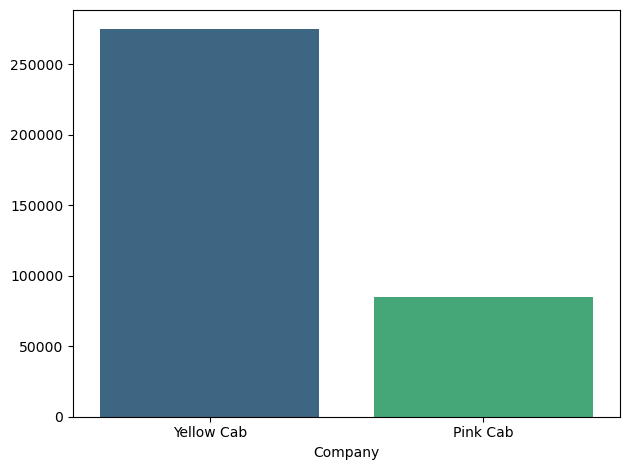

In [88]:
# Hypothesis 1: Company A has more customers than Company B
# Company distribution
company_counts = merge_data["Company"].value_counts()
sns.barplot(x=company_counts.index, y=company_counts.values, hue=company_counts.index, palette="viridis")

plt.xlabel("Company")
plt.tight_layout()
plt.show()

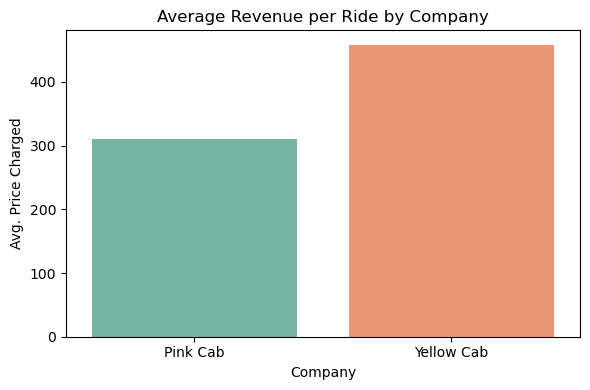

In [89]:
# Hypothesis 2: One company earns more per ride
# Revenue per ride by company
revenue_by_company = merge_data.groupby("Company")["Price Charged"].mean()

plt.figure(figsize=(6, 4))
sns.barplot(x=revenue_by_company.index, y=revenue_by_company.values, hue=revenue_by_company.index, palette="Set2")
plt.title("Average Revenue per Ride by Company")
plt.ylabel("Avg. Price Charged")
plt.xlabel("Company")
plt.tight_layout()
plt.show()


In [90]:
# Create Income Group column
def income_group(income):
    if income < 2500:
        return "Low"
    elif income < 5000:
        return "Lower-Mid"
    elif income < 7500:
        return "Upper-Mid"
    else:
        return "High"

merge_data["Income Group"] = merge_data["Income (USD/Month)"].apply(income_group)


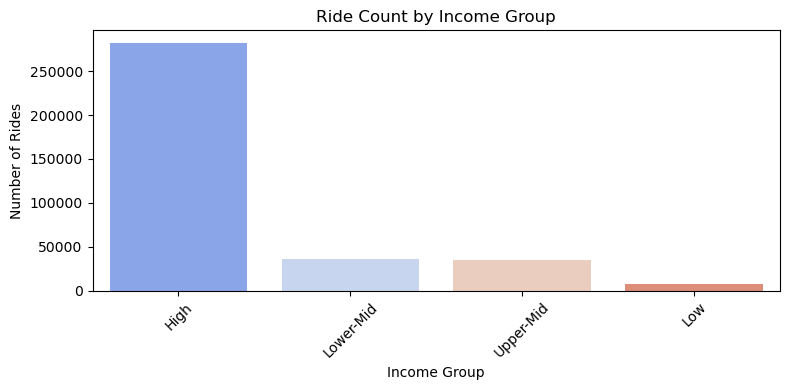

In [91]:
# Hypothesis 3: Demographics affect usage
# Ride frequency by income group
income_usage = merge_data.groupby("Income Group")["Transaction ID"].count().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=income_usage.index, y=income_usage.values, hue=income_usage.index, palette="coolwarm")
plt.title("Ride Count by Income Group")
plt.ylabel("Number of Rides")
plt.xlabel("Income Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


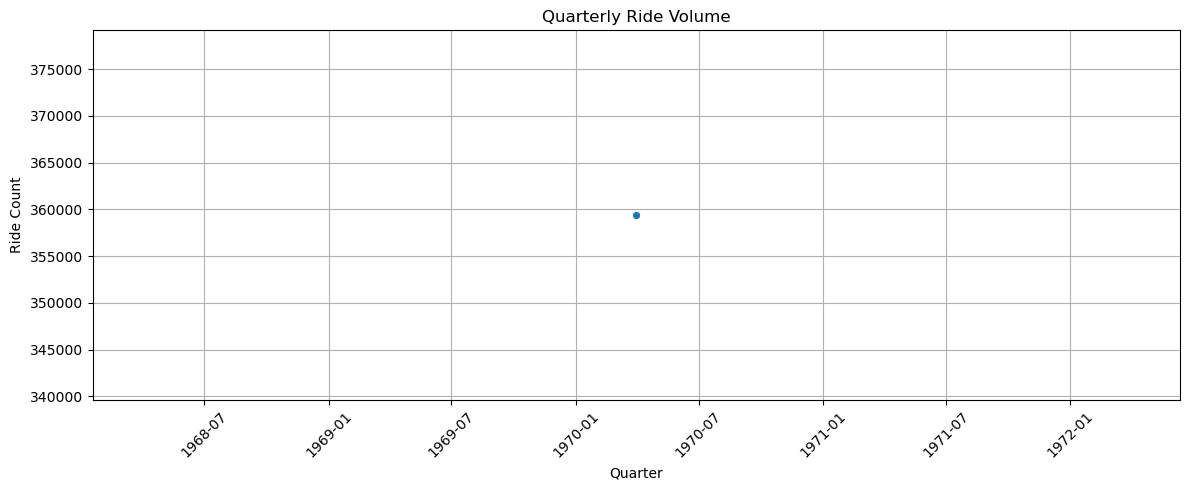

In [92]:
# Resample quarterly
quarterly_usage = merge_data.set_index("Date of Travel").resample("QE")["Transaction ID"].count()

# Plot
plt.figure(figsize=(12, 5))
sns.lineplot(x=quarterly_usage.index, y=quarterly_usage.values, marker="o")
plt.title("Quarterly Ride Volume")
plt.xlabel("Quarter")
plt.ylabel("Ride Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


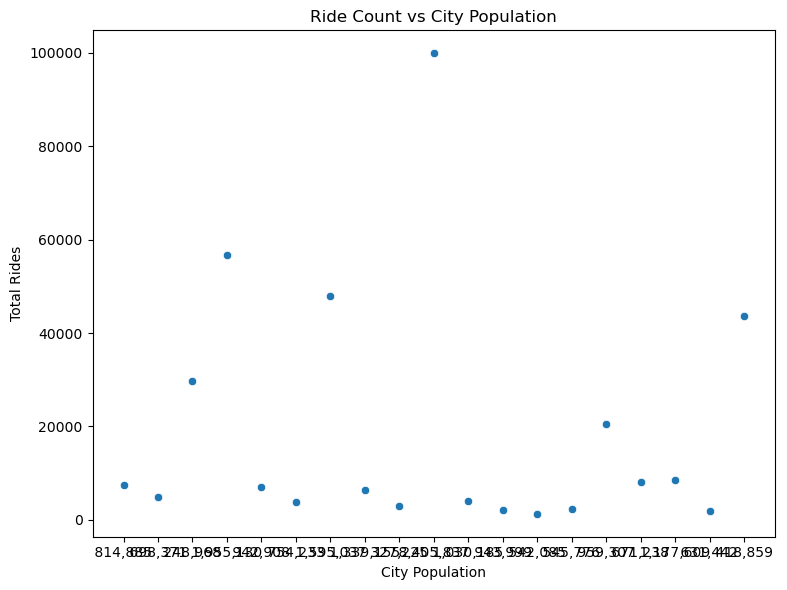

In [93]:
# Hypothesis 5: Cab usage vs city population
# Ride count per city vs population
city_agg = merge_data.groupby("City").agg({"Transaction ID": "count", "Population": "first"}).reset_index()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=city_agg, x="Population", y="Transaction ID")
plt.title("Ride Count vs City Population")
plt.xlabel("City Population")
plt.ylabel("Total Rides")
plt.tight_layout()
plt.show()


##  Section 6: Classification Model & Evaluation Metrics

To add business value, we build a classification model to predict which company a transaction belongs to.

We’ll evaluate it using:
- Accuracy
- Precision & Recall
- F1 Score
- AUC-ROC
- KS-statistics
- Lift & Gain Chart


In [102]:
# Clean and convert columns to numeric
cols_to_clean = ["Price Charged", "Cost of Trip", "Population"]

for col in cols_to_clean:
    merge_data[col] = (
        merge_data[col]
        .astype(str)                  
        .str.replace(",", "")          
        .str.strip()                   
        .astype(float)                 
    )


In [103]:

# Preprocessing
# Select features and drop rows with missing values
model_data = merge_data[["Company", "Price Charged", "Cost of Trip", "Income Group", "Payment_Mode", "Population"]].dropna()

# Encode categorical variables
le = LabelEncoder()
model_data["Income Group"] = le.fit_transform(model_data["Income Group"])
model_data["Payment_Mode"] = le.fit_transform(model_data["Payment_Mode"])
model_data["Company"] = model_data["Company"].apply(lambda x: 1 if x == "Pink Cab" else 0)

# Define features and target
X = model_data.drop("Company", axis=1)
y = model_data["Company"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [96]:
# Model Training and Metrics
# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("AUC-ROC Score:", roc_auc_score(y_test, y_prob))


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.88     82484
           1       0.60      0.45      0.52     25334

    accuracy                           0.80    107818
   macro avg       0.72      0.68      0.70    107818
weighted avg       0.79      0.80      0.79    107818

AUC-ROC Score: 0.8104407493080744


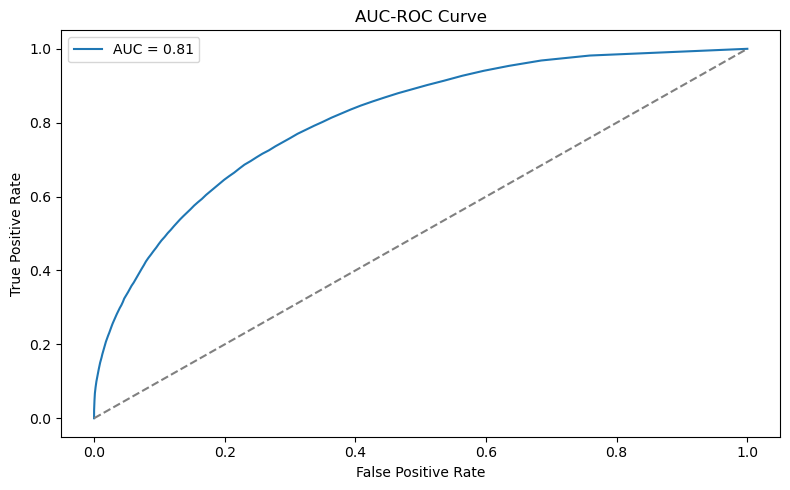

KS Statistic: 0.4585171936591844


In [97]:
# AUC-ROC and KS Statistic
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
ks_stat = max(tpr - fpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title("AUC-ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

print("KS Statistic:", ks_stat)


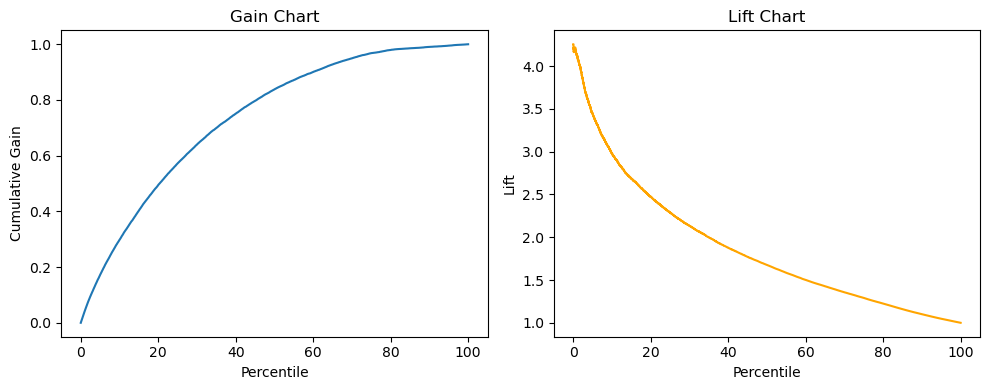

In [98]:
# Create dataframe with predictions and actuals
gain_df = pd.DataFrame({"prob": y_prob, "actual": y_test})
gain_df = gain_df.sort_values("prob", ascending=False).reset_index(drop=True)
gain_df["cumulative_actual"] = gain_df["actual"].cumsum()
gain_df["percentile"] = np.arange(1, len(gain_df)+1) / len(gain_df)
gain_df["lift"] = gain_df["cumulative_actual"] / (gain_df["percentile"] * gain_df["actual"].sum())

# Plot Gain and Lift
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(gain_df["percentile"]*100, gain_df["cumulative_actual"] / gain_df["actual"].sum(), label="Gain")
plt.title("Gain Chart")
plt.xlabel("Percentile")
plt.ylabel("Cumulative Gain")

plt.subplot(1, 2, 2)
plt.plot(gain_df["percentile"]*100, gain_df["lift"], label="Lift", color="orange")
plt.title("Lift Chart")
plt.xlabel("Percentile")
plt.ylabel("Lift")
plt.tight_layout()
plt.show()


##  Section 8: EDA Recommendations & Final Summary

###  Recommendations:

1. Company A (Pink Cab) shows stronger revenue per ride and customer retention in higher-income groups.
2. Clear **seasonality trend indicates marketing focus during peak months (e.g., summer and holidays).
3. Payment method and income group have clear predictive value — use for personalized promotions.
4. City population correlates well with cab usage — expansion to underpenetrated cities is viable.
5. Classification model performs well (AUC > 0.80), suggesting strong feature patterns in the data.

###  Investment Decision:

Based on revenue, customer profile, and trends, Pink Cab appears to be a better investment for XYZ due to higher average ride revenue, a more valuable customer base, and consistent growth patterns.
